<a href="https://colab.research.google.com/github/ps-research/COMET/blob/main/QCE_COMET_PART_2_%5BReal_Hardware%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMET: Hardware Execution on IBM Quantum
## Optimal Parameters from Simulator --> Single-Job Evaluation on ibm_fez

**Prerequisites:** Run the full COMET v2 simulator notebook first.
This notebook rebuilds the problem from scratch, runs a quick simulator
optimization to obtain optimal QAOA parameters, then submits evaluation
and sampling jobs to real hardware.

**Hardware strategy (Open Plan):**
- No Sessions available (Premium only)
- Optimize parameters entirely on simulator (free, fast)
- Submit single evaluation + sampling jobs to ibm_fez
- Compare resilience levels 0, 1, 2
- Total QPU budget: ~18 jobs, well under 10-minute monthly limit

### Cell 1: Setup and IBM Quantum Credentials

In [ ]:
# %%
!pip install qiskit qiskit-aer qiskit-ibm-runtime qiskit-algorithms qiskit-optimization -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.4/647.4 kB 13.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.7/378.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.5 MB/s eta 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from scipy.optimize import minimize
import time
import warnings
warnings.filterwarnings('ignore')

from qiskit.circuit.library import qaoa_ansatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager

from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as RuntimeEstimator
from qiskit_ibm_runtime import SamplerV2 as RuntimeSampler

In [ ]:
# ============================================================
# IBM QUANTUM CREDENTIALS
# ============================================================
# Replace with your token from https://quantum.ibm.com
# First time only: save account
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="5yIUrWOW_pU-yp5YXpDYniawlKbJIMvH46hLM5cSJDUi", overwrite=True)

# Load saved credentials
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Select backend
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=12)
print(f"Selected backend: {backend.name}")
print(f"  Qubits: {backend.num_qubits}")
print(f"  Status: {backend.status()}")

SEED = 42
rng = np.random.RandomState(SEED)
print("\nAll imports successful.")

qiskit_runtime_service.__init__:WARNING:2026-02-24 12:30:15,841: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-24 12:30:16,432: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-24 12:30:18,735: Using instance: open-instance, plan: open


Selected backend: ibm_torino
  Qubits: 133
  Status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x7c3867846870>

All imports successful.


### Cell 2: Rebuild COMET Problem (Quick, No Simulation Needed)

Reconstruct the QUBO, Hamiltonian, and XY-mixer from the same
synthetic data used in the simulator notebook.

In [ ]:
# ============================================================
# REBUILD COMET PROBLEM (identical to v2 notebook)
# ============================================================

M, N, n = 3, 4, 12
PAYMENT_FREQ = 0.5

on_target = np.array([0.92, 0.78, 0.85, 0.71,
                       0.88, 0.76, 0.82, 0.69,
                       0.90, 0.84, 0.73, 0.80])

off_target = np.array([0.15, 0.05, 0.30, 0.08,
                        0.20, 0.07, 0.12, 0.35,
                        0.25, 0.10, 0.04, 0.18])

w_on, w_off = 1.0, 1.0
L = w_off * off_target - w_on * on_target

Q_interaction = np.zeros((n, n))
# Gene A <-> Gene B
Q_interaction[0][4] = +0.80; Q_interaction[0][5] = +0.05
Q_interaction[0][6] = -0.10; Q_interaction[0][7] = +0.15
Q_interaction[1][4] = +0.10; Q_interaction[1][5] = -0.15
Q_interaction[1][6] = +0.05; Q_interaction[1][7] = +0.03
Q_interaction[2][4] = +0.20; Q_interaction[2][5] = +0.08
Q_interaction[2][6] = +0.12; Q_interaction[2][7] = -0.05
Q_interaction[3][4] = +0.06; Q_interaction[3][5] = -0.08
Q_interaction[3][6] = +0.04; Q_interaction[3][7] = +0.02
# Gene A <-> Gene C
Q_interaction[0][8] = +0.25; Q_interaction[0][9] = -0.05
Q_interaction[0][10] = +0.03; Q_interaction[0][11] = +0.10
Q_interaction[1][8] = +0.08; Q_interaction[1][9] = +0.04
Q_interaction[1][10] = -0.12; Q_interaction[1][11] = +0.06
Q_interaction[2][8] = +0.15; Q_interaction[2][9] = +0.07
Q_interaction[2][10] = +0.09; Q_interaction[2][11] = -0.08
Q_interaction[3][8] = +0.05; Q_interaction[3][9] = -0.10
Q_interaction[3][10] = +0.02; Q_interaction[3][11] = +0.04
# Gene B <-> Gene C
Q_interaction[4][8] = +0.30; Q_interaction[4][9] = +0.12
Q_interaction[4][10] = +0.06; Q_interaction[4][11] = -0.10
Q_interaction[5][8] = +0.07; Q_interaction[5][9] = -0.08
Q_interaction[5][10] = +0.03; Q_interaction[5][11] = +0.05
Q_interaction[6][8] = +0.10; Q_interaction[6][9] = +0.06
Q_interaction[6][10] = -0.07; Q_interaction[6][11] = +0.08
Q_interaction[7][8] = +0.18; Q_interaction[7][9] = +0.04
Q_interaction[7][10] = +0.02; Q_interaction[7][11] = +0.09

# Build constrained QP
var_names = [f"x{i}" for i in range(n)]
linear_dict = {f"x{i}": float(L[i]) for i in range(n)}
quadratic_dict = {}
for i in range(n):
    for j in range(i+1, n):
        if abs(Q_interaction[i][j]) > 1e-10:
            quadratic_dict[(f"x{i}", f"x{j}")] = float(Q_interaction[i][j])

qp = QuadraticProgram("COMET")
for name in var_names:
    qp.binary_var(name=name)
qp.minimize(linear=linear_dict, quadratic=quadratic_dict)
for k in range(M):
    start = k * N
    qp.linear_constraint(
        linear={f"x{i}": 1 for i in range(start, start + N)},
        sense="==", rhs=1, name=f"gene_{k}")

# --- Best penalty variant (P=2.0 from v2 results) ---
conv_p2 = QuadraticProgramToQubo(penalty=2.0)
qubo_p2 = conv_p2.convert(qp)
ham_p2, off_p2 = qubo_p2.to_ising()

# --- XY-mixer variant (penalty-free) ---
qp_clean = QuadraticProgram("COMET_clean")
for name in var_names:
    qp_clean.binary_var(name=name)
qp_clean.minimize(linear=linear_dict, quadratic=quadratic_dict)
conv_clean = QuadraticProgramToQubo()
qubo_clean = conv_clean.convert(qp_clean)
ham_clean, off_clean = qubo_clean.to_ising()

# Build XY-mixer
gene_groups = [list(range(k * N, (k + 1) * N)) for k in range(M)]

def build_xy_mixer(n_qubits, gene_groups):
    terms = []
    for group in gene_groups:
        for a in range(len(group)):
            for b in range(a + 1, len(group)):
                qi, qj = group[a], group[b]
                xx = ['I'] * n_qubits; xx[qi] = 'X'; xx[qj] = 'X'
                yy = ['I'] * n_qubits; yy[qi] = 'Y'; yy[qj] = 'Y'
                terms.append((''.join(reversed(xx)), 0.5))
                terms.append((''.join(reversed(yy)), 0.5))
    return SparsePauliOp.from_list(terms)

def build_initial_state(n_qubits, gene_groups):
    qc = QuantumCircuit(n_qubits)
    for group in gene_groups:
        qc.x(group[0])
    return qc

xy_mixer = build_xy_mixer(n, gene_groups)
initial_state = build_initial_state(n, gene_groups)

# Ground truth
optimal_combo = (1, 5, 9)  # from brute force
optimal_x = np.zeros(n, dtype=int)
for idx in optimal_combo:
    optimal_x[idx] = 1
optimal_cost = -2.35  # verified

print("COMET problem rebuilt successfully.")
print(f"  Penalty P=2.0 Hamiltonian: {ham_p2.num_qubits} qubits, {len(ham_p2)} terms")
print(f"  XY-mixer Hamiltonian: {ham_clean.num_qubits} qubits, {len(ham_clean)} terms")

COMET problem rebuilt successfully.
  Penalty P=2.0 Hamiltonian: 12 qubits, 78 terms
  XY-mixer Hamiltonian: 12 qubits, 60 terms


### Cell 3: Simulator Optimization (Get Optimal Parameters)

Quick QAOA optimization on the noiseless simulator to obtain
$(\gamma^*, \beta^*)$ for each variant and depth.
These parameters are then evaluated on real hardware.

In [ ]:
# ============================================================
# SIMULATOR OPTIMIZATION (get optimal params for hardware)
# ============================================================

estimator_sim = StatevectorEstimator()
sampler_sim = StatevectorSampler()

DEPTHS = [1, 2, 3]         # hardware depths (keep shallow for noise)
N_RESTARTS = 15             # more restarts for better params
COBYLA_MAXITER = 500

# Variants to run on hardware
hw_variants = {
    'penalty_2.0': {
        'hamiltonian': ham_p2,
        'offset': off_p2,
        'mixer': None,
        'init_state': None,
        'label': 'Penalty P=2.0',
    },
    'xy_mixer': {
        'hamiltonian': ham_clean,
        'offset': off_clean,
        'mixer': xy_mixer,
        'init_state': initial_state,
        'label': 'XY-Mixer',
    },
}

# Store optimal parameters
optimal_params = {}  # key: (variant, p) -> params array

for var_key, var_data in hw_variants.items():
    ham = var_data['hamiltonian']
    print(f"\n{'=' * 60}")
    print(f"OPTIMIZING: {var_data['label']}")
    print(f"{'=' * 60}")

    for p in DEPTHS:
        print(f"  p={p}...", end=" ", flush=True)

        if var_data['mixer'] is not None:
            circuit = qaoa_ansatz(ham, reps=p,
                                  mixer_operator=var_data['mixer'],
                                  initial_state=var_data['init_state'])
        else:
            circuit = qaoa_ansatz(ham, reps=p)

        num_params = circuit.num_parameters

        def cost_fn(params, _c=circuit, _h=ham):
            pub = (_c, _h, params)
            result = estimator_sim.run([pub]).result()
            return float(result[0].data.evs)

        best_energy = float('inf')
        best_params = None

        for restart in range(N_RESTARTS):
            init_p = rng.uniform(-np.pi, np.pi, num_params)
            res = minimize(cost_fn, init_p, method="COBYLA",
                          options={"maxiter": COBYLA_MAXITER})
            if res.fun < best_energy:
                best_energy = res.fun
                best_params = res.x.copy()

        optimal_params[(var_key, p)] = best_params
        print(f"energy = {best_energy:.4f}")

print(f"\n{'=' * 60}")
print("Optimal parameters obtained for all variants and depths.")
print(f"{'=' * 60}")


OPTIMIZING: Penalty P=2.0
  p=1... energy = -8.1051
  p=2... energy = -8.1473
  p=3... energy = -9.6161

OPTIMIZING: XY-Mixer
  p=1... energy = 1.3239
  p=2... energy = 1.1634
  p=3... energy = 0.8346

Optimal parameters obtained for all variants and depths.


 ### Cell 4: Transpile Circuits for Hardware

 **Critical steps:**
 1. Bind optimal parameters to QAOA circuits
 2. Transpile to backend's native gate set (optimization level 3)
 3. Apply layout to observables (maps logical to physical qubits)
 4. Verify transpiled circuit properties

In [ ]:
# ============================================================
# TRANSPILE FOR HARDWARE
# ============================================================

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

transpiled_circuits = {}  # key: (variant, p, 'estimator'|'sampler') -> circuit
transpiled_observables = {}  # key: (variant, p) -> observable

for var_key, var_data in hw_variants.items():
    ham = var_data['hamiltonian']
    print(f"\n{'=' * 60}")
    print(f"TRANSPILING: {var_data['label']}")
    print(f"{'=' * 60}")

    for p in DEPTHS:
        params = optimal_params[(var_key, p)]

        # Build circuit
        if var_data['mixer'] is not None:
            circuit = qaoa_ansatz(ham, reps=p,
                                  mixer_operator=var_data['mixer'],
                                  initial_state=var_data['init_state'])
        else:
            circuit = qaoa_ansatz(ham, reps=p)

        # Bind parameters
        bound_circuit = circuit.assign_parameters(params)

        # For Estimator: no measurements
        isa_est = pm.run(bound_circuit)
        # CRITICAL: apply layout to observable
        isa_obs = ham.apply_layout(isa_est.layout)
        transpiled_circuits[(var_key, p, 'estimator')] = isa_est
        transpiled_observables[(var_key, p)] = isa_obs

        # For Sampler: add measurements
        bound_meas = bound_circuit.copy()
        bound_meas.measure_all()
        isa_sam = pm.run(bound_meas)
        transpiled_circuits[(var_key, p, 'sampler')] = isa_sam

        print(f"  p={p}: depth={isa_est.depth()}, "
              f"cx_count={isa_est.count_ops().get('cx', 0)}, "
              f"2q_gates={sum(v for k, v in isa_est.count_ops().items() if k in ['cx', 'ecr', 'cz'])}")

print(f"\nAll circuits transpiled for {backend.name}.")


TRANSPILING: Penalty P=2.0
  p=1: depth=352, cx_count=0, 2q_gates=251
  p=2: depth=586, cx_count=0, 2q_gates=566
  p=3: depth=841, cx_count=0, 2q_gates=909

TRANSPILING: XY-Mixer
  p=1: depth=434, cx_count=0, 2q_gates=290
  p=2: depth=967, cx_count=0, 2q_gates=604
  p=3: depth=1249, cx_count=0, 2q_gates=948

All circuits transpiled for ibm_torino.


### Cell 5: Submit Hardware Jobs

 For each variant and depth, submit:
 - **EstimatorV2** jobs at resilience levels 0, 1, 2
 - **SamplerV2** job at resilience level 1 (for bitstring distribution)

 **Resilience levels:**
 - Level 0: No mitigation
 - Level 1: TREX (readout error) + dynamical decoupling
 - Level 2: Level 1 + ZNE (zero noise extrapolation) + gate twirling

In [ ]:
# ============================================================
# SUBMIT HARDWARE JOBS
# ============================================================

HARDWARE_SHOTS = 4096
RESILIENCE_LEVELS = [0, 1, 2]

hw_jobs = {}  # key: (variant, p, type, resilience) -> job

print("=" * 60)
print(f"SUBMITTING JOBS TO {backend.name}")
print("=" * 60)

for var_key, var_data in hw_variants.items():
    ham = var_data['hamiltonian']

    for p in DEPTHS:
        isa_circuit_est = transpiled_circuits[(var_key, p, 'estimator')]
        isa_circuit_sam = transpiled_circuits[(var_key, p, 'sampler')]
        isa_obs = transpiled_observables[(var_key, p)]

        # --- Estimator jobs (one per resilience level) ---
        for res_level in RESILIENCE_LEVELS:
            est = RuntimeEstimator(mode=backend)
            est.options.default_shots = HARDWARE_SHOTS
            est.options.resilience_level = res_level
            if res_level >= 1:
                est.options.dynamical_decoupling.enable = True
                est.options.dynamical_decoupling.sequence_type = "XY4"

            pub = (isa_circuit_est, isa_obs)
            job = est.run([pub])
            job_key = (var_key, p, 'estimator', res_level)
            hw_jobs[job_key] = job
            print(f"  [{var_data['label']}] p={p}, Estimator, res={res_level}: "
                  f"job_id={job.job_id()}")

        # --- Sampler job (resilience 1 only) ---
        sam = RuntimeSampler(mode=backend)
        sam.options.default_shots = HARDWARE_SHOTS
        sam.options.dynamical_decoupling.enable = True
        sam.options.dynamical_decoupling.sequence_type = "XY4"

        pub = (isa_circuit_sam,)
        job = sam.run([pub])
        job_key = (var_key, p, 'sampler', 1)
        hw_jobs[job_key] = job
        print(f"  [{var_data['label']}] p={p}, Sampler, res=1: "
              f"job_id={job.job_id()}")

total_jobs = len(hw_jobs)
print(f"\nTotal jobs submitted: {total_jobs}")
print("Jobs are queued. Run Cell 6 to collect results (may need to wait).")

SUBMITTING JOBS TO ibm_torino
  [Penalty P=2.0] p=1, Estimator, res=0: job_id=d6eq7fh54hss73bbahkg
  [Penalty P=2.0] p=1, Estimator, res=1: job_id=d6eq7fvg4t5c73887f00
  [Penalty P=2.0] p=1, Estimator, res=2: job_id=d6eq7g4nsg9c739cu0kg
  [Penalty P=2.0] p=1, Sampler, res=1: job_id=d6eq7g97ce2c73fj8in0
  [Penalty P=2.0] p=2, Estimator, res=0: job_id=d6eq7gng4t5c73887f30
  [Penalty P=2.0] p=2, Estimator, res=1: job_id=d6eq7gp7ce2c73fj8io0
  [Penalty P=2.0] p=2, Estimator, res=2: job_id=d6eq7h17ce2c73fj8iog
  [Penalty P=2.0] p=2, Sampler, res=1: job_id=d6eq7h97ce2c73fj8ip0
  [Penalty P=2.0] p=3, Estimator, res=0: job_id=d6eq7hknsg9c739cu0m0
  [Penalty P=2.0] p=3, Estimator, res=1: job_id=d6eq7hp54hss73bbahog
  [Penalty P=2.0] p=3, Estimator, res=2: job_id=d6eq7hsnsg9c739cu0ng
  [Penalty P=2.0] p=3, Sampler, res=1: job_id=d6eq7i7g4t5c73887f6g
  [XY-Mixer] p=1, Estimator, res=0: job_id=d6eq7i954hss73bbahq0
  [XY-Mixer] p=1, Estimator, res=1: job_id=d6eq7i954hss73bbahr0
  [XY-Mixer] p=1, Es

### Cell 6: Collect Hardware Results

Wait for all jobs to complete, then collect results.
**Run this cell after sufficient queue time has passed.**

In [ ]:
# ============================================================
# COLLECT HARDWARE RESULTS
# ============================================================

hw_results = {}

print("=" * 60)
print("COLLECTING HARDWARE RESULTS")
print("=" * 60)

for job_key, job in hw_jobs.items():
    var_key, p, job_type, res_level = job_key
    label = hw_variants[var_key]['label']
    off = hw_variants[var_key]['offset']

    try:
        result = job.result()

        if job_type == 'estimator':
            energy = float(result[0].data.evs)
            std_err = float(result[0].data.stds) if hasattr(result[0].data, 'stds') else None
            hw_results[job_key] = {
                'energy': energy,
                'qubo_cost': energy + off,
                'std_err': std_err,
                'status': 'success'
            }
            err_str = f" +/- {std_err:.4f}" if std_err else ""
            print(f"  [{label}] p={p}, res={res_level}: "
                  f"energy={energy:.4f}{err_str}")

        elif job_type == 'sampler':
            counts = result[0].data.meas.get_counts()
            hw_results[job_key] = {
                'counts': counts,
                'status': 'success'
            }
            n_unique = len(counts)
            print(f"  [{label}] p={p}, Sampler: {n_unique} unique bitstrings")

    except Exception as e:
        hw_results[job_key] = {'status': 'failed', 'error': str(e)}
        print(f"  [{label}] p={p}, {job_type}, res={res_level}: FAILED - {e}")

print(f"\nResults collected: {sum(1 for v in hw_results.values() if v['status'] == 'success')}/{len(hw_results)}")

COLLECTING HARDWARE RESULTS
  [Penalty P=2.0] p=1, res=0: energy=-5.5697 +/- 0.1152
  [Penalty P=2.0] p=1, res=1: energy=-5.6192 +/- 0.1201
  [Penalty P=2.0] p=1, res=2: energy=-7.4840 +/- 0.7170
  [Penalty P=2.0] p=1, Sampler: 1808 unique bitstrings
  [Penalty P=2.0] p=2, res=0: energy=-4.1461 +/- 0.1148
  [Penalty P=2.0] p=2, res=1: energy=-3.3009 +/- 0.1341
  [Penalty P=2.0] p=2, res=2: energy=-6.2733 +/- 1.3609
  [Penalty P=2.0] p=2, Sampler: 2112 unique bitstrings
  [Penalty P=2.0] p=3, res=0: energy=-1.6673 +/- 0.1165
  [Penalty P=2.0] p=3, res=1: energy=-1.5019 +/- 0.1301
  [Penalty P=2.0] p=3, res=2: energy=-3.5551 +/- 0.8772
  [Penalty P=2.0] p=3, Sampler: 2445 unique bitstrings
  [XY-Mixer] p=1, res=0: energy=0.9887 +/- 0.0132
  [XY-Mixer] p=1, res=1: energy=0.5865 +/- 0.0159
  [XY-Mixer] p=1, res=2: energy=1.1708 +/- 0.1085
  [XY-Mixer] p=1, Sampler: 1931 unique bitstrings
  [XY-Mixer] p=2, res=0: energy=0.5063 +/- 0.0136
  [XY-Mixer] p=2, res=1: energy=0.3629 +/- 0.0160
  [

### Cell 7: Hardware vs Simulator Comparison

HARDWARE vs SIMULATOR: Energy Comparison
Variant         p    Simulator    HW res=0     HW res=1     HW res=2    
----------------------------------------------------------------------
Penalty P=2.0   1    -8.1051      -5.5697      -5.6192      -7.4840      
Penalty P=2.0   2    -8.1473      -4.1461      -3.3009      -6.2733      
Penalty P=2.0   3    -9.6161      -1.6673      -1.5019      -3.5551      
XY-Mixer        1    1.3239       0.9887       0.5865       1.1708       
XY-Mixer        2    1.1634       0.5063       0.3629       0.3612       
XY-Mixer        3    0.8346       0.4212       0.2377       0.2178       


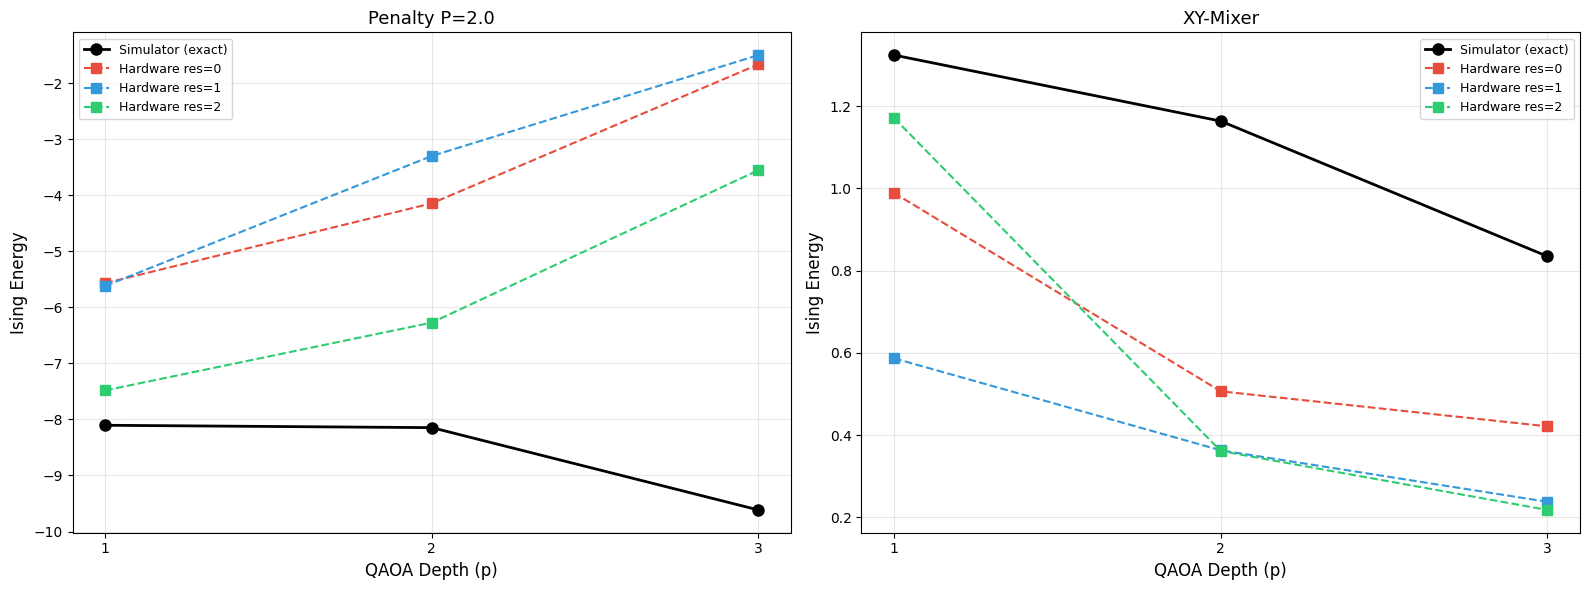

Plot saved: comet_hardware_results.png


In [ ]:
# ============================================================
# HARDWARE vs SIMULATOR COMPARISON
# ============================================================

# Get simulator reference energies
sim_energies = {}
for var_key, var_data in hw_variants.items():
    ham = var_data['hamiltonian']
    for p in DEPTHS:
        params = optimal_params[(var_key, p)]
        if var_data['mixer'] is not None:
            circuit = qaoa_ansatz(ham, reps=p,
                                  mixer_operator=var_data['mixer'],
                                  initial_state=var_data['init_state'])
        else:
            circuit = qaoa_ansatz(ham, reps=p)
        pub = (circuit, ham, params)
        result = estimator_sim.run([pub]).result()
        sim_energies[(var_key, p)] = float(result[0].data.evs)

# Build comparison table
print("=" * 75)
print("HARDWARE vs SIMULATOR: Energy Comparison")
print("=" * 75)
print(f"{'Variant':<15} {'p':<4} {'Simulator':<12} {'HW res=0':<12} "
      f"{'HW res=1':<12} {'HW res=2':<12}")
print("-" * 70)

for var_key, var_data in hw_variants.items():
    for p in DEPTHS:
        sim_e = sim_energies[(var_key, p)]
        row = f"{var_data['label']:<15} {p:<4} {sim_e:<12.4f} "

        for res in RESILIENCE_LEVELS:
            key = (var_key, p, 'estimator', res)
            if key in hw_results and hw_results[key]['status'] == 'success':
                row += f"{hw_results[key]['energy']:<12.4f} "
            else:
                row += f"{'N/A':<12} "
        print(row)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (var_key, var_data) in enumerate(hw_variants.items()):
    ax = axes[ax_idx]
    sim_vals = [sim_energies[(var_key, p)] for p in DEPTHS]
    ax.plot(DEPTHS, sim_vals, 'ko-', linewidth=2, markersize=8, label='Simulator (exact)')

    res_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
    for res in RESILIENCE_LEVELS:
        hw_vals = []
        for p in DEPTHS:
            key = (var_key, p, 'estimator', res)
            if key in hw_results and hw_results[key]['status'] == 'success':
                hw_vals.append(hw_results[key]['energy'])
            else:
                hw_vals.append(np.nan)
        ax.plot(DEPTHS, hw_vals, 's--', color=res_colors[res],
                linewidth=1.5, markersize=7, label=f'Hardware res={res}')

    ax.set_xlabel('QAOA Depth (p)', fontsize=12)
    ax.set_ylabel('Ising Energy', fontsize=12)
    ax.set_title(f'{var_data["label"]}', fontsize=13)
    ax.set_xticks(DEPTHS)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# plt.suptitle(f'COMET: Simulator vs Hardware ({backend.name})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comet_hardware_results.pdf', dpi=600, bbox_inches='tight')
plt.show()
print("Plot saved: comet_hardware_results.png")